# Exercise 1 - Estimation and Sampling

Fundamental topics of statistics and inference, this exercise focuses on estimating the parameters of a distribution (mean and variance) from random samples.

Objectives: <br></br>
    1. Understand the concept of sampling: How to generate random data from a known distribution. <br>
    2. Estimate the parameters of a distribution: Use of sample mean and sample variance to approximate the parameters of a normal distribution. <br>
    3. Visualize and compare distributions: Use of graphs to compare the theoretical distribution and the estimated one. <br>
    4. Evaluate the quality of the estimate: Calculation of the mean squared error (MSE) between the theoretical distribution and the estimated one. <br>

# Cell 1 - Importing Libraries
• numpy: Library for numerical processing and scientific computing <br>
• numpy.random.default_rng: Random number generator <br>
• scipy.stats.multivariate_normal: Function for working with multivariate normal distributions. <br>
• matplotlib.pyplot: Library for graphical visualization. <br>

In [2]:
import numpy as np
from numpy.random import default_rng
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

# Cell 2 - Definition of the plotting function

Definition of the function for visualizing the theoretical distribution and the estimated one, and calculating the estimation error <br>

`mu`: mean of the theoretical normal distribution from which the data were generated<br>
`sigma`: standard deviation of the theoretical normal distribution<br>
`mu_hat`: estimate of the sample mean<br>
`sigma2_hat`: estimate of the variance obtained from the sampled data<br>
`data`: set of samples drawn from the normal distribution<br>
`num_data`: number of generated samples<br>

In [17]:
# utility function for plot the estimated gaussians

def plot_estimate(mu, sigma, mu_hat, sigma2_hat, data, num_data):
#     plt.figure(figsize=(7,7))
    
    plt.minorticks_on()
    
    x = np.linspace(mu - 3 *sigma, mu + 3 * sigma, 500)
    
    y = multivariate_normal([mu], [sigma**2])
    y_hat = multivariate_normal([mu_hat],[sigma2_hat])
    
    plt.scatter(data, np.zeros((num_data,)), marker='x', c='r', label='Samples')
    plt.plot(x, y.pdf(x), c='g', label='Theoretical distribution')
    plt.plot(x, y_hat.pdf(x),label='Estimated distribution')
    
    mse = np.sum((y.pdf(data)-y_hat.pdf(data))**2)/num_data
    
    plt.text(-0.6, 0.45,\
            f'Estimated sample mean: {mu_hat:4.2f}\nEstimated variance: {sigma2_hat:4.2f}\nMSE: {mse:6.4f}',\
            fontsize=12)
    
    plt.legend()
    
    plt.show()

In [4]:
# Define mu, sigma and num_data
mu = 1.5
sigma = 0.7
num_data = 100

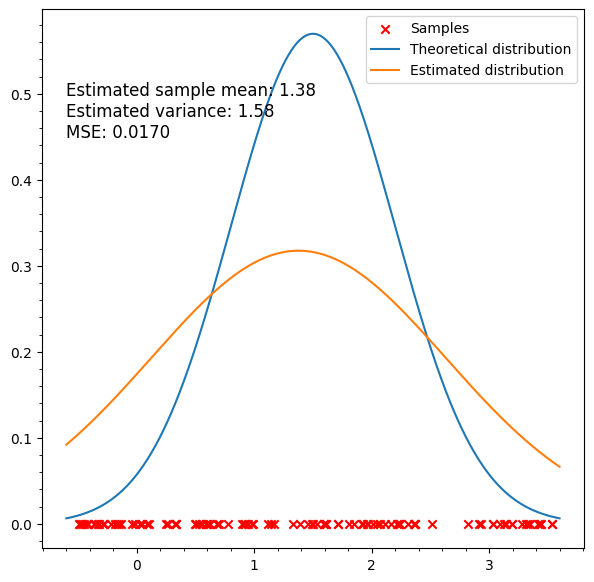

In [5]:
# Uniform sampling
# data generation

rg = default_rng()

data = rg.uniform(mu - 3*sigma, mu + 3*sigma, num_data)

def uniform_estimate(data, num_data):
    
    # mean
    mu_hat = np.sum(data)/num_data
    
    # variance from formula 
    sigma2_hat = np.sum((data - mu_hat)**2)/(num_data - 1)
    
    return (mu_hat, sigma2_hat)

mu_hat, sigma2_hat = uniform_estimate(data, num_data)
plot_estimate(mu, sigma, mu_hat, sigma2_hat, data, num_data)

In [6]:
# Let's run a simulation by estimating the values of mean and
# variance multiple times to see their expected values

simulations = 100

mhs = np.zeros((simulations,), dtype=np.float64)
sigmahs = np.zeros((simulations,), dtype=np.float64)

for i in range(simulations):
    
    data = rg.uniform(mu - 3*sigma, mu + 3*sigma, num_data)
    
    mhs[i], sigmahs[i] = uniform_estimate(data, num_data)

mh = np.sum(mhs)/simulations
sh = np.sum(sigmahs)/simulations

print(f'Mean expected value: {mh:4.2f}\nVariance expected value: {sh:4.2f}')

Mean expected value: 1.50
Variance expected value: 1.47


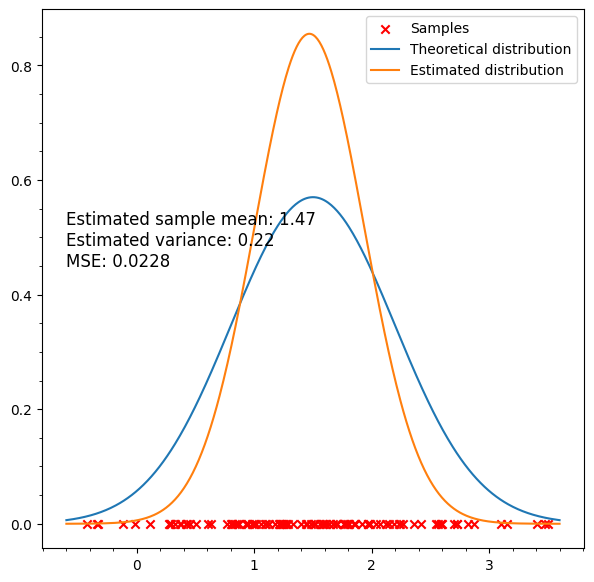

Variance of the mean estimator: 0.00039


In [7]:
# Stratified sampling w/ sigma intervals as strata

# S_k/S per k = 1, ..., 6
# population_per_stratum = np.array([0.031, 0.136, 0.341, 0.341, 0.136, 0.031])
population_per_stratum = np.array([0.05, 0.15, 0.30, 0.30, 0.15, 0.05])

num_strata = 6

# Enumeration of the number of samples per stratum n_k per k = 1, ..., 6
samples_per_stratum = np.array(num_data*population_per_stratum,dtype=int)

# What if n_k constant?
#samples_per_stratum = np.full((6,),2,dtype='int')

def stratified_estimate(num_strata, population_per_stratum, samples_per_stratum):
    
    data = np.empty((num_data,),dtype=np.float64)
    
    mu_per_stratum = np.empty((num_strata,),dtype='float64')
    sigma2_per_stratum = np.empty((num_strata,),dtype='float64')
    
    i = 0
    start = mu - 3*sigma
    
    # iterate per stratum
    for k in range(0,len(samples_per_stratum)):
        
        data[i:i+samples_per_stratum[k]] = rg.uniform(start, start+sigma, samples_per_stratum[k])
        
        # we estimate the mean and variance at stratum level using the formulas
        mu_per_stratum[k] = np.sum(data[i:i+samples_per_stratum[k]])/samples_per_stratum[k]
        sigma2_per_stratum[k] = np.sum((data[i:i+samples_per_stratum[k]]-mu_per_stratum[k])**2)\
                                            /(samples_per_stratum[k]-1)
                                    
        i = i + samples_per_stratum[k]
        start += sigma
    
    # Summation with k of (S_k/S)*mu_k
    # population_per_stratum is already in percentage
    mu_hat = np.sum(population_per_stratum*mu_per_stratum)
    
    sigma2_hat = np.sum(sigma2_per_stratum)
    
    # Variance of the mean estimator
    # population_per_stratum is already in percentage
    var_mu_hat = np.sum((population_per_stratum**2)*sigma2_per_stratum/samples_per_stratum)

    return (mu_hat, sigma2_hat, var_mu_hat, data)

mu_hat, sigma2_hat, var_mu_hat, data = stratified_estimate(num_strata,\
                                                        population_per_stratum,\
                                                        samples_per_stratum)

plot_estimate(mu, sigma, mu_hat, sigma2_hat, data, num_data)

print(f'Variance of the mean estimator: {var_mu_hat:7.5f}')

In [8]:
# Simulation on 100 runs of stratified sampling

mhs = np.zeros((simulations,), dtype=np.float64)
sigmahs = np.zeros((simulations,), dtype=np.float64)

for i in range(simulations):
        
    mhs[i], sigmahs[i], _, _ = stratified_estimate(num_strata, population_per_stratum, samples_per_stratum)

mh = np.sum(mhs)/simulations
sh = np.sum(sigmahs)/simulations

print(f'Expected value of the mean: {mh:4.2f}\nExpected value of the variance: {sh:4.2f}')

Expected value of the mean: 1.50
Expected value of the variance: 0.24


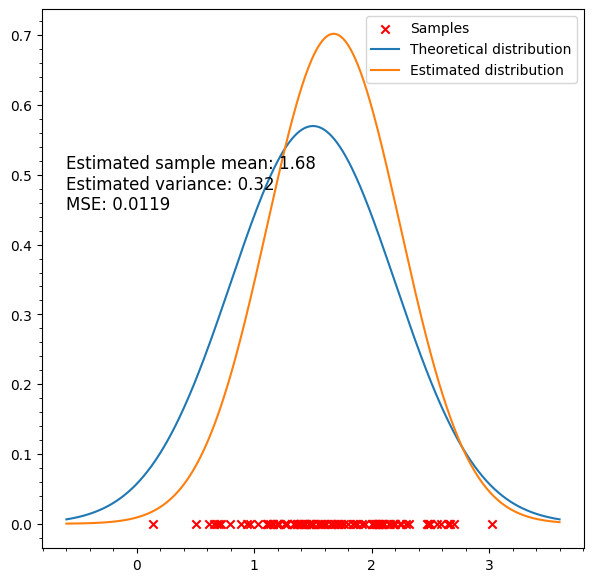

In [9]:
# Importance sampling

def importance_estimate(num_data, scaling):
    
    rg = default_rng()

    # Extract samples for the importance function with a uniform distribution
    samples_importance = rg.uniform(mu - 3 * sigma, mu + 3 * sigma, num_data)
    
    # Calculate the parameters of the importance function as sample estimates
    # on the values extracted through the uniform distribution

    mu_importance = np.sum(samples_importance)/num_data
    
    sigma2_importance = np.sum((samples_importance-mu_importance)**2)/(num_data-1)
    
    # Sample the data for the estimate using the importance function, with scaling equal to q
    data = rg.normal(mu_importance, scaling*np.sqrt(sigma2_importance),num_data)
    
    # Estimate mean and variance of the data
    mu_hat = np.sum(data)/num_data
    sigma2_hat = np.sum((data - mu_hat)**2)/(num_data-1)
    
    return (mu_hat, sigma2_hat, data)


mu_hat, sigma2_hat, data = importance_estimate(num_data, 0.55)

plot_estimate(mu, sigma, mu_hat, sigma2_hat, data, num_data)  

In [10]:
def simulation(num_data, sim=100, scale=0.7):
    
    mh = np.zeros((sim,),dtype='float64')
    sh = np.zeros((sim,),dtype='float64')
    
    for i in range(sim):
        
        mh[i], sh[i], _ = importance_estimate(num_data, scale)
    
    
    mh_hat = np.sum(mh)/sim
    sh_hat = np.sum(sh)/sim
    
    return (mh_hat, sh_hat)

mh_hat, sh_hat = simulation(num_data)

print(f'Mean expected value: {mh_hat:4.2f}\nVariance expected value: {sh_hat:4.2f}')

Mean expected value: 1.48
Variance expected value: 0.71


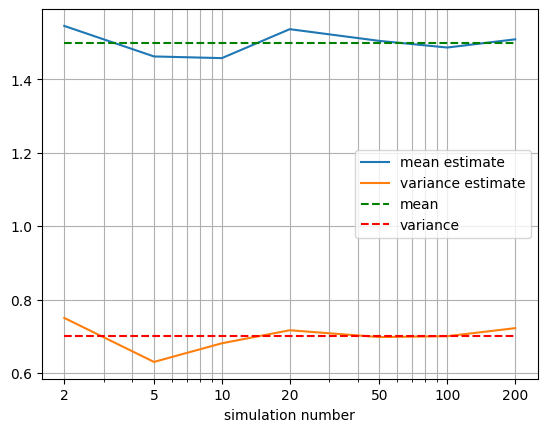

In [11]:
# Create graphs that represent the trend of expected values
# of mean and variance as the number of simulations varies

runs = np.array([2, 5, 10, 20, 50, 100, 200])

mhs = np.empty((7,),dtype='float64')
shs = np.empty((7,),dtype='float64')

x = np.arange(2, 201, 1)

med = np.full((199,),mu)
var = np.full((199,),sigma)

for i in range(len(runs)):
    
    mhs[i], shs[i] = simulation(num_data, sim=runs[i])

plt.grid(True, which='both')

plt.semilogx(runs, mhs, label='mean estimate')
plt.semilogx(runs, shs, label='variance estimate')

plt.xlabel('simulation number')
plt.xticks(runs, runs)

plt.plot(x, med, 'g--', label='mean')
plt.plot(x, var, 'r--', label='variance')

plt.legend()

plt.show()


In [21]:
print(sh_hat, mh_hat)

0.7107996009836586 1.4821250016479595


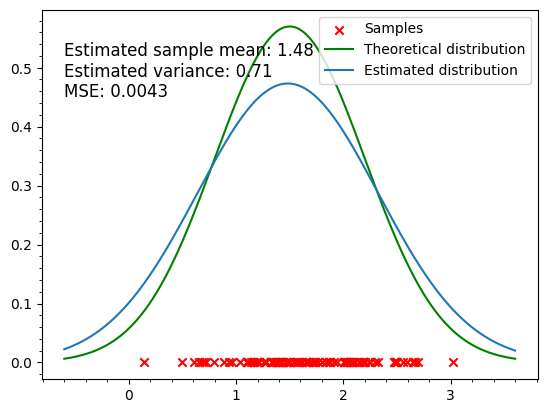

In [18]:
plot_estimate(mu, sigma, mh_hat, sh_hat, data, num_data) 

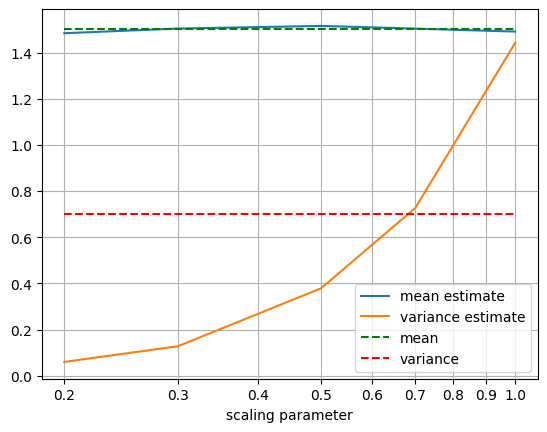

In [11]:
# Create graphs that represent the trend of expected values
# of mean and variance as the number of scaling parameter

scales = np.array([0.2, 0.3, 0.5, 0.7, 1.0])

mhs = np.empty((5,),dtype='float64')
shs = np.empty((5,),dtype='float64')

x = np.arange(0.2, 1.05, 0.05)

med = np.full((len(x),),mu)
var = np.full((len(x),),sigma)

for i in range(len(scales)):
    
    mhs[i], shs[i] = simulation(num_data, scale=scales[i])

plt.grid(True, which='both')

plt.semilogx(scales, mhs, label='mean estimate')
plt.semilogx(scales, shs, label='variance estimate')

plt.xlabel('scaling parameter')
plt.xticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.plot(x, med, 'g--', label='mean')
plt.plot(x, var, 'r--', label='variance')

plt.legend()

plt.show()